In [2]:
import pandas as pd
import numpy as np

In [3]:
date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='h')
df = pd.DataFrame(date_rng, columns=['timestamp'])

In [4]:
df['fridge'] = np.random.randint(50, 200, len(df)) * np.random.choice([0,1], len(df), p=[0.3,0.7])

In [5]:
month = df['timestamp'].dt.month
ac_prob = np.where(month >= 4, 0.8, 0.1)
df['ac'] = np.random.randint(1000, 2500, len(df)) * np.random.binomial(1, ac_prob)

In [6]:
hour = df['timestamp'].dt.hour
light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)

df['lights'] = np.random.randint(20, 100, len(df)) * np.random.binomial(1, light_prob)
df['microwave'] = np.random.randint(800, 1200, len(df)) * np.random.choice([0,1], len(df), p=[0.9,0.1])

In [7]:
df['total_power'] = df[['fridge','ac','lights','microwave']].sum(axis=1)
df.head()

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,199,0,0,0,199
1,2023-01-01 01:00:00,139,2075,31,0,2245
2,2023-01-01 02:00:00,101,0,79,0,180
3,2023-01-01 03:00:00,136,0,39,1181,1356
4,2023-01-01 04:00:00,83,0,71,0,154


In [8]:
#analysis.ipynb

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
#data understanding

In [10]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    4321 non-null   datetime64[us]
 1   fridge       4321 non-null   int64         
 2   ac           4321 non-null   int32         
 3   lights       4321 non-null   int32         
 4   microwave    4321 non-null   int64         
 5   total_power  4321 non-null   int64         
dtypes: datetime64[us](1), int32(2), int64(3)
memory usage: 168.9 KB


,timestamp,fridge,ac,lights,microwave,total_power
count,4321,4321.000000,4321.000000,4321.000000,4321.000000,4321.000000
mean,2023-04-01 00:00:00,86.988429,800.310808,31.947929,102.270771,1021.517936
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-02-15 00:00:00,0.000000,0.000000,0.000000,0.000000,122.000000
50%,2023-04-01 00:00:00,93.000000,0.000000,25.000000,0.000000,1006.000000
75%,2023-05-16 00:00:00,147.000000,1679.000000,62.000000,0.000000,1883.000000
max,2023-06-30 00:00:00,199.000000,2499.000000,99.000000,1198.000000,3835.000000
std,NaN,67.666522,921.147074,34.274239,304.131366,973.142794


In [ ]:
## Trend Analysis

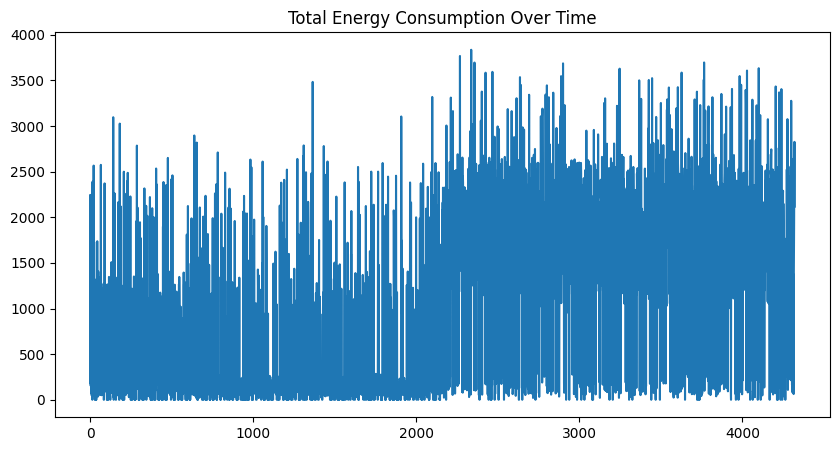

In [11]:
import matplotlib.pyplot as plt

df['total_power'].plot(figsize=(10,5))
plt.title("Total Energy Consumption Over Time")
plt.show()

In [ ]:
## Device Comparison

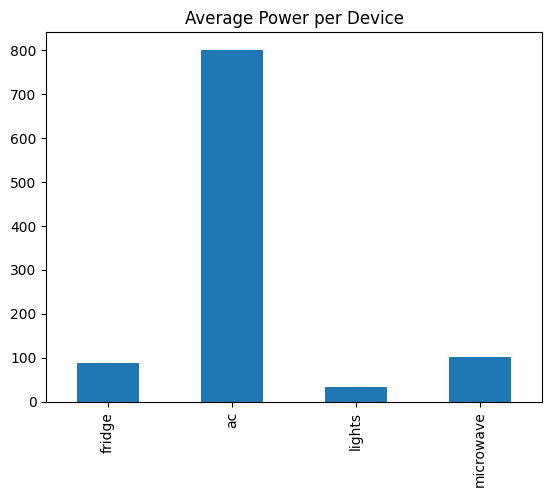

In [12]:
df[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Average Power per Device")
plt.show()

In [ ]:
## Time Analysis

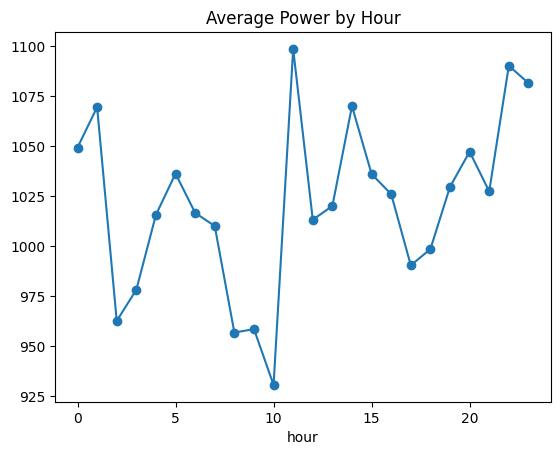

In [13]:
df['hour'] = df['timestamp'].dt.hour

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
## Relationship Analysis

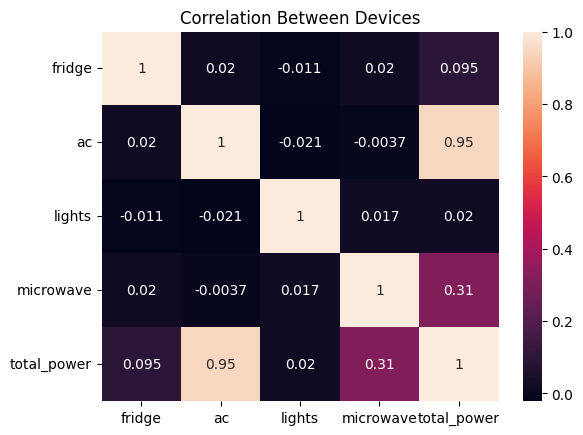

In [14]:
import seaborn as sns

sns.heatmap(df[['fridge','ac','lights','microwave','total_power']].corr(), annot=True)
plt.title("Correlation Between Devices")
plt.show()

In [ ]:
## Time Series Decomposition

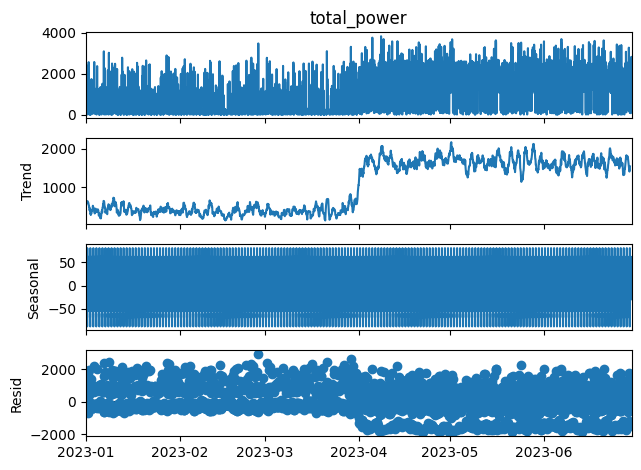

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Decomposition (daily pattern → 24 hours)
decomposition = seasonal_decompose(df['total_power'], model='additive', period=24)

# Plot
decomposition.plot()
plt.show()

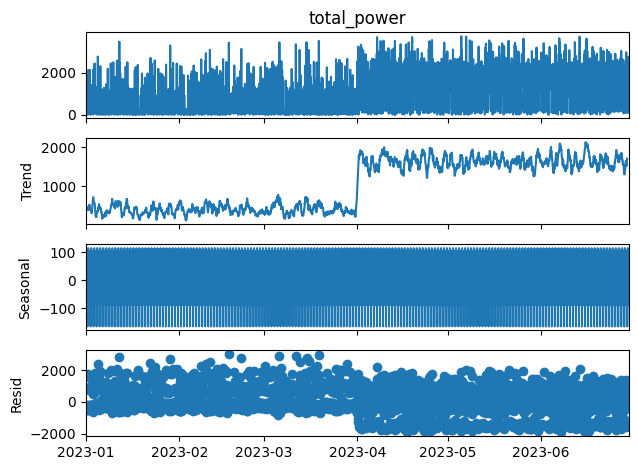

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition using index
result = seasonal_decompose(df['total_power'], model='additive', period=24)

result.plot()
plt.show()

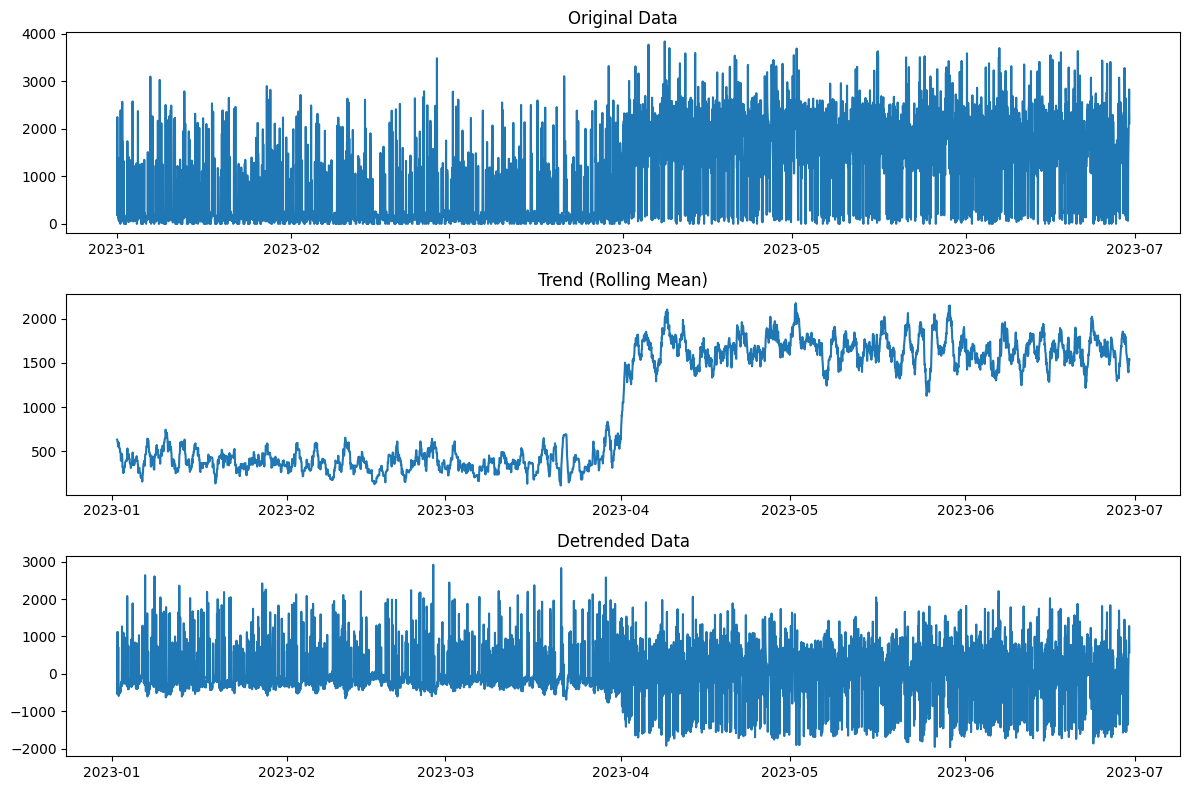

In [16]:
import matplotlib.pyplot as plt

# Make sure timestamp is index
df = df.copy()
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)

# 1. Trend (using rolling mean)
df['trend'] = df['total_power'].rolling(window=24).mean()

# 2. Detrended (remove trend)
df['detrended'] = df['total_power'] - df['trend']

# 3. Plot everything
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(df['total_power'])
plt.title("Original Data")

plt.subplot(3,1,2)
plt.plot(df['trend'])
plt.title("Trend (Rolling Mean)")

plt.subplot(3,1,3)
plt.plot(df['detrended'])
plt.title("Detrended Data")

plt.tight_layout()
plt.show()

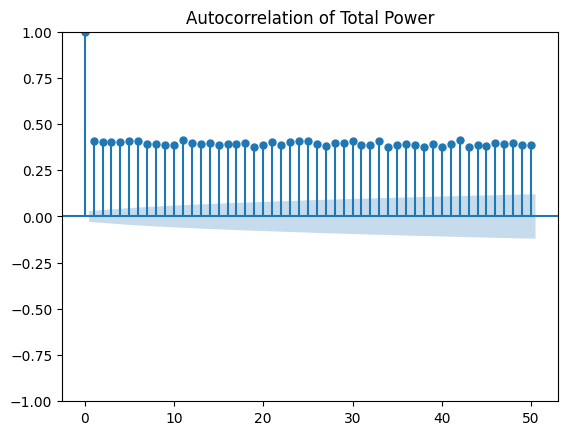

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['total_power'], lags=50)
plt.title("Autocorrelation of Total Power")
plt.show()

In [ ]:
## Partial Autocorrelation (PACF)

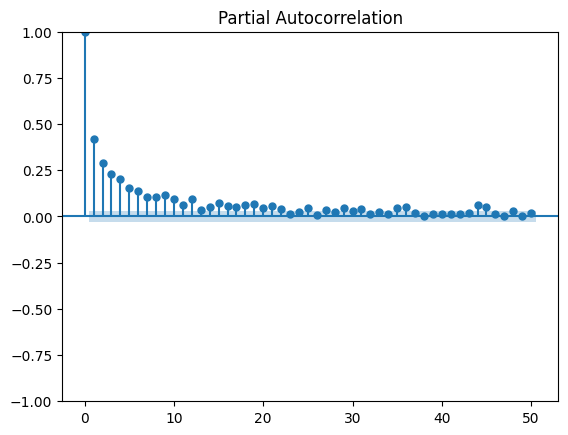

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['total_power'], lags=50)
plt.title("Partial Autocorrelation")
plt.show()

In [ ]:
#hourly.ipynb

In [18]:
df['hour'] = df.index.hour
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended
timestamp,,,,,,,,
2023-01-01 00:00:00,199,0,0,0,199,0,NaN,NaN
2023-01-01 01:00:00,139,2075,31,0,2245,1,NaN,NaN
2023-01-01 02:00:00,101,0,79,0,180,2,NaN,NaN
2023-01-01 03:00:00,136,0,39,1181,1356,3,NaN,NaN
2023-01-01 04:00:00,83,0,71,0,154,4,NaN,NaN


In [ ]:
##hourly table

In [19]:
hourly_table = df.groupby('hour').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

hourly_table

total_power               fridge          ac     lights   microwave
             mean   max min       mean        mean       mean        mean
hour                                                                     
0     1049.430939  3406   0  82.425414  826.668508  51.679558   88.657459
1     1069.644444  3584   0  87.022222  846.522222  56.988889   79.111111
2      962.783333  3449   0  79.361111  713.455556  53.172222  116.794444
3      978.333333  3585  20  96.338889  666.122222  52.961111  162.911111
4     1015.805556  3433   0  85.122222  745.694444  51.738889  133.250000
5     1036.394444  3695   0  87.416667  778.944444  54.616667  115.416667
6     1016.794444  3228   0  87.661111  806.316667  51.244444   71.572222
7     1010.183333  3628   0  87.277778  832.277778   5.527778   85.100000
8      956.972222  3546   0  82.472222  764.911111   7.700000  101.888889
9      958.661111  3835   0  85.516667  784.322222   7.355556   81.466667
10     930.772222  3318   0  79.933333  761.544444   6.927778   82.366667
11    1098.722222  3291   0  91.372222  829.572222   5.955556  171.822222
12    1013.338889  3767   0  85.277778  839.300000   3.061111   85.700000
13    1020.216667  3246   0  88.922222  849.294444   5.072222   76.927778
14    1070.116667  3524   0  83.722222  887.505556   5.150000   93.738889
15    1036.194444  3404   0  98.705556  838.511111   6.511111   92.466667
16    1026.122222  3206   0  91.711111  819.400000   7.900000  107.111111
17     990.538889  3445   0  93.555556  763.744444   6.850000  126.388889
18     998.672222  3504   0  81.644444  753.483333  54.638889  108.905556
19    1029.783333  3593   0  87.911111  828.266667  51.866667   61.738889
20    1047.350000  3686   0  89.738889  813.077778  51.094444   93.438889
21    1027.494444  3696   0  85.683333  786.716667  54.511111  100.583333
22    1090.305556  3096   0  89.022222  835.522222  57.827778  107.933333
23    1081.644444  3547   0  79.933333  836.138889  56.288889  109.283333

In [ ]:
##average power by hour

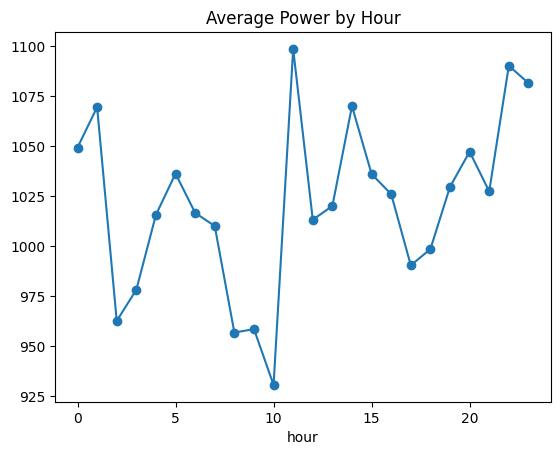

In [20]:
import matplotlib.pyplot as plt

df.groupby('hour')['total_power'].mean().plot(marker='o')
plt.title("Average Power by Hour")
plt.show()

In [ ]:
##maximum power by hour

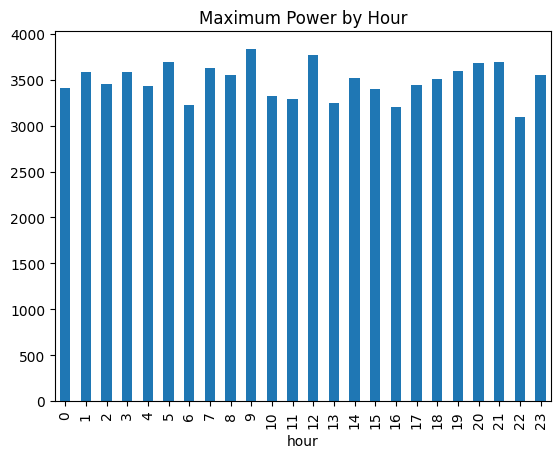

In [21]:
df.groupby('hour')['total_power'].max().plot(kind='bar')
plt.title("Maximum Power by Hour")
plt.show()

In [ ]:
##minimum power by hour

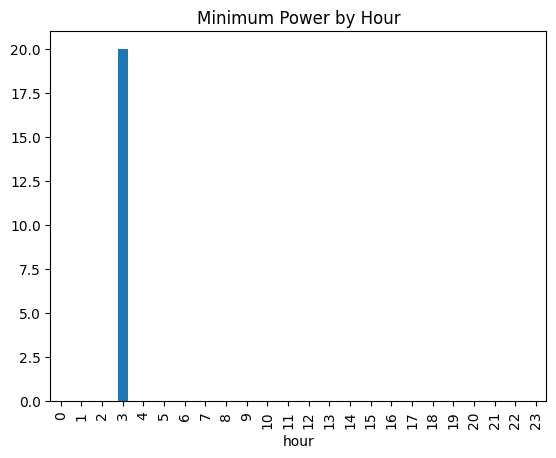

In [22]:
df.groupby('hour')['total_power'].min().plot(kind='bar')
plt.title("Minimum Power by Hour")
plt.show()

In [ ]:
##Device-wise Hourly Usage

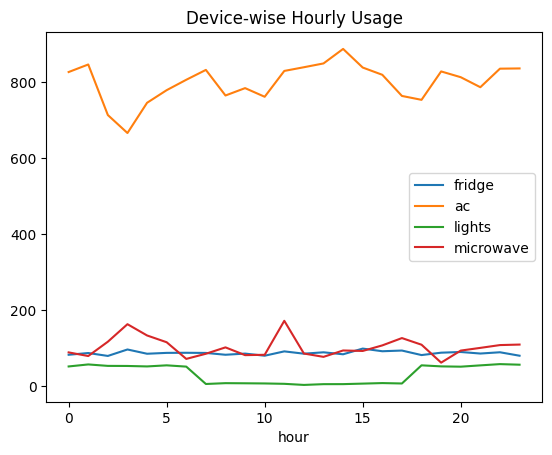

In [23]:
df.groupby('hour')[['fridge','ac','lights','microwave']].mean().plot()
plt.title("Device-wise Hourly Usage")
plt.show()

In [ ]:
##Peak Hour Detection

In [24]:
peak_hour = df.groupby('hour')['total_power'].mean().idxmax()
print("Peak usage hour:", peak_hour)

Peak usage hour: 11


In [ ]:
##weekly.ipynb

In [25]:
df['day_type'] = df.index.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type
timestamp,,,,,,,,,
2023-01-01 00:00:00,199,0,0,0,199,0,NaN,NaN,Weekend
2023-01-01 01:00:00,139,2075,31,0,2245,1,NaN,NaN,Weekend
2023-01-01 02:00:00,101,0,79,0,180,2,NaN,NaN,Weekend
2023-01-01 03:00:00,136,0,39,1181,1356,3,NaN,NaN,Weekend
2023-01-01 04:00:00,83,0,71,0,154,4,NaN,NaN,Weekend


In [ ]:
##weeday vs weekend

In [26]:
daytype_table = df.groupby('day_type').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

daytype_table

total_power               fridge          ac     lights   microwave
                 mean   max min       mean        mean       mean        mean
day_type                                                                     
Weekday   1013.275105  3767   0  86.683242  794.062318  32.278334  100.251211
Weekend   1042.374183  3835   0  87.760621  816.120915  31.111928  107.380719

In [ ]:
##Compare Total Power

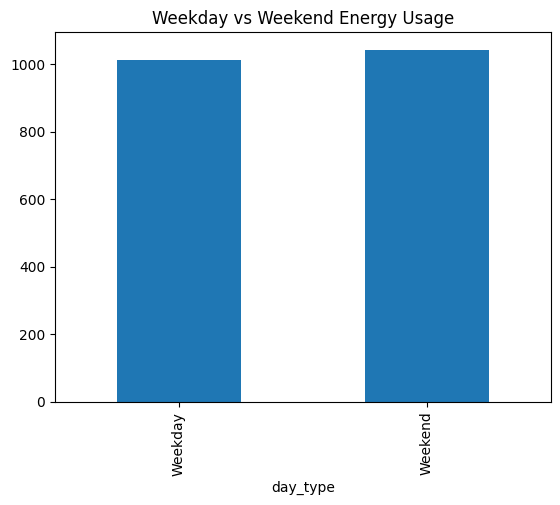

In [27]:
import matplotlib.pyplot as plt

df.groupby('day_type')['total_power'].mean().plot(kind='bar')
plt.title("Weekday vs Weekend Energy Usage")
plt.show()

In [ ]:
##Hourly Pattern for Weekday vs Weekend

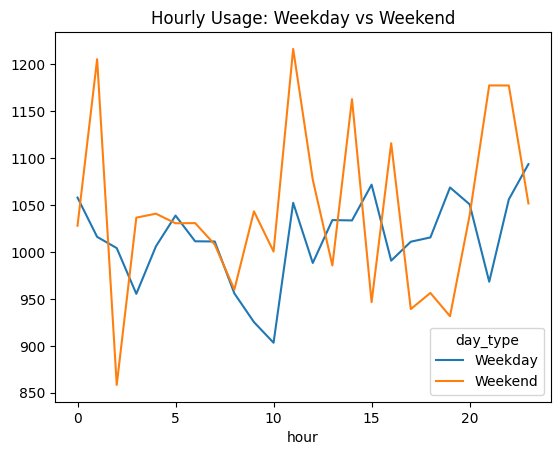

In [28]:
df['hour'] = df.index.hour

df.groupby(['hour','day_type'])['total_power'].mean().unstack().plot()
plt.title("Hourly Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Device-wise Comparison

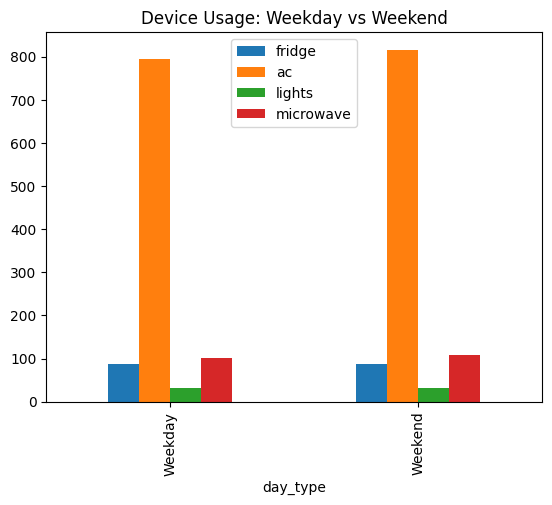

In [29]:
df.groupby('day_type')[['fridge','ac','lights','microwave']].mean().plot(kind='bar')
plt.title("Device Usage: Weekday vs Weekend")
plt.show()

In [ ]:
##Peak Time (Weekday vs Weekend) 

In [30]:
peak = df.groupby(['hour','day_type'])['total_power'].mean().reset_index()

weekday_peak = peak[peak['day_type']=='Weekday'].sort_values('total_power', ascending=False).iloc[0]
weekend_peak = peak[peak['day_type']=='Weekend'].sort_values('total_power', ascending=False).iloc[0]

print("Weekday Peak Hour:", weekday_peak['hour'])
print("Weekend Peak Hour:", weekend_peak['hour'])

Weekday Peak Hour: 23
Weekend Peak Hour: 11


In [ ]:
##Energy Difference (Insight Program)

In [31]:
weekday_avg = df[df['day_type']=='Weekday']['total_power'].mean()
weekend_avg = df[df['day_type']=='Weekend']['total_power'].mean()

print("Weekday Avg:", weekday_avg)
print("Weekend Avg:", weekend_avg)
print("Difference:", weekend_avg - weekday_avg)

Weekday Avg: 1013.2751049402648
Weekend Avg: 1042.374183006536
Difference: 29.099078066271204


In [ ]:
##monthly.ipynb

In [32]:
df['month'] = df.index.month
df['month_name'] = df.index.month_name()
df.head()

,fridge,ac,lights,microwave,total_power,hour,trend,detrended,day_type,month,month_name
timestamp,,,,,,,,,,,
2023-01-01 00:00:00,199,0,0,0,199,0,NaN,NaN,Weekend,1,January
2023-01-01 01:00:00,139,2075,31,0,2245,1,NaN,NaN,Weekend,1,January
2023-01-01 02:00:00,101,0,79,0,180,2,NaN,NaN,Weekend,1,January
2023-01-01 03:00:00,136,0,39,1181,1356,3,NaN,NaN,Weekend,1,January
2023-01-01 04:00:00,83,0,71,0,154,4,NaN,NaN,Weekend,1,January


In [ ]:
##Monthly Summary Table 

In [33]:
monthly_table = df.groupby('month_name').agg({
    'total_power': ['mean','max','min'],
    'fridge': 'mean',
    'ac': 'mean',
    'lights': 'mean',
    'microwave': 'mean'
})

monthly_table

total_power               fridge           ac     lights  \
                   mean   max min       mean         mean       mean   
month_name                                                             
April       1656.029167  3835   0  87.040278  1433.202778  32.088889   
February     368.141369  3483   0  86.708333   157.800595  32.974702   
January      406.276882  3096   0  88.310484   187.977151  32.115591   
June        1621.883788  3696   0  81.880918  1405.329986  31.845050   
March        389.422043  3318   0  86.333333   171.219086  32.259409   
May         1682.518817  3686   0  91.309140  1442.793011  30.501344   

             microwave  
                  mean  
month_name              
April       103.697222  
February     90.657738  
January      97.873656  
June        102.827834  
March        99.610215  
May         117.915323

In [ ]:
##Total Power by Month

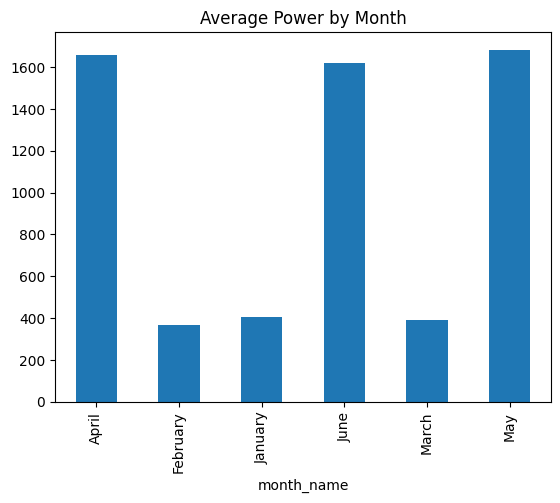

In [34]:
import matplotlib.pyplot as plt

df.groupby('month_name')['total_power'].mean().plot(kind='bar')
plt.title("Average Power by Month")
plt.show()

In [ ]:
##Compare Few Months

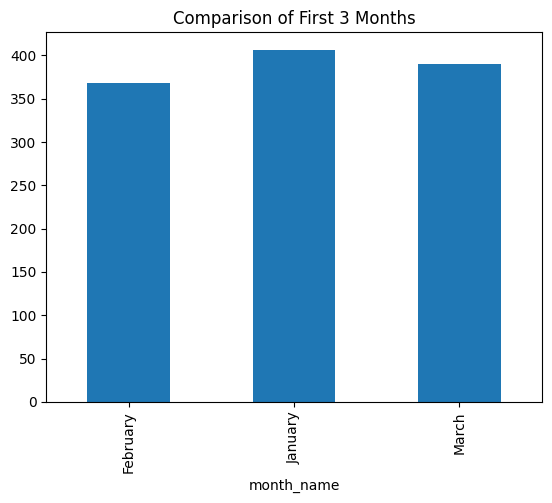

In [35]:
selected_months = ['January','February','March']

df[df['month_name'].isin(selected_months)] \
.groupby('month_name')['total_power'].mean() \
.plot(kind='bar')

plt.title("Comparison of First 3 Months")
plt.show()

In [ ]:
##Device Usage for Few Months 

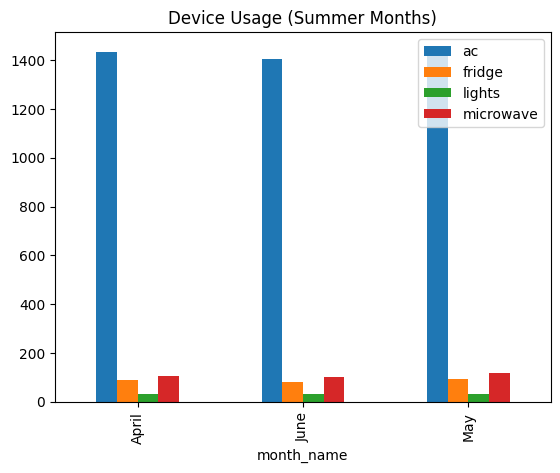

In [36]:
df[df['month_name'].isin(['April','May','June'])] \
.groupby('month_name')[['ac','fridge','lights','microwave']] \
.mean().plot(kind='bar')

plt.title("Device Usage (Summer Months)")
plt.show()

In [ ]:
##Monthly Peak Detection

In [37]:
peak_month = df.groupby('month_name')['total_power'].mean().idxmax()
print("Peak usage month:", peak_month)

Peak usage month: May


In [ ]:
##Monthly Trend Line 

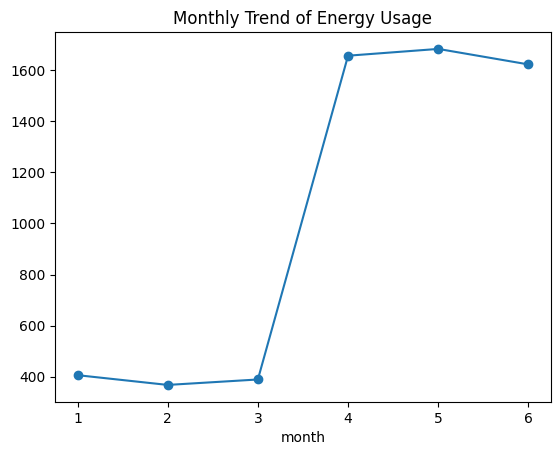

In [38]:
df.groupby('month')['total_power'].mean().plot(marker='o')
plt.title("Monthly Trend of Energy Usage")
plt.show()

In [ ]:
##Winter vs Summer comparison

In [39]:
winter = ['January','February','March']
summer = ['April','May','June']

print("Winter Avg:", df[df['month_name'].isin(winter)]['total_power'].mean())
print("Summer Avg:", df[df['month_name'].isin(summer)]['total_power'].mean())

Winter Avg: 388.6069444444444
Summer Avg: 1654.1360481258675


In [ ]:
## AC usage increase

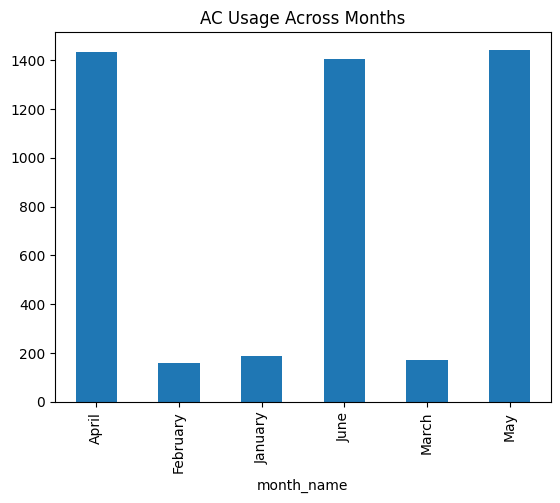

In [40]:
df.groupby('month_name')['ac'].mean().plot(kind='bar')
plt.title("AC Usage Across Months")
plt.show()

In [ ]:
##polynomial.ipynb

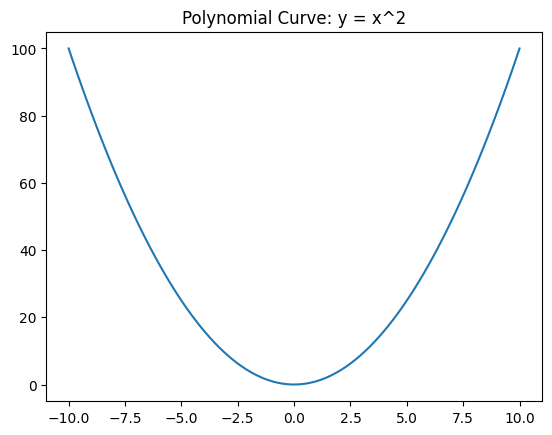

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = x**2

plt.plot(x, y)
plt.title("Polynomial Curve: y = x^2")
plt.show()

In [ ]:
##multiple polynomial curves

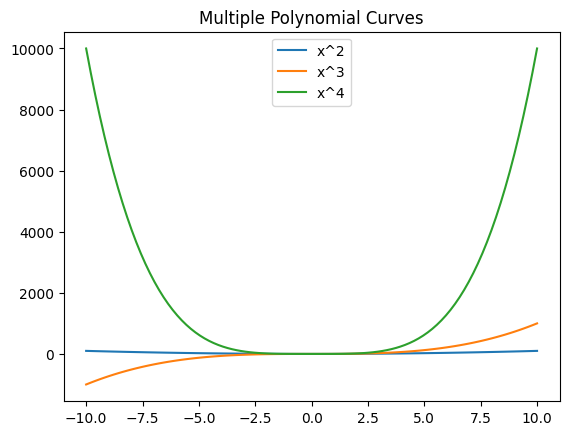

In [42]:
x = np.linspace(-10, 10, 100)

plt.plot(x, x**2, label="x^2")
plt.plot(x, x**3, label="x^3")
plt.plot(x, x**4, label="x^4")

plt.legend()
plt.title("Multiple Polynomial Curves")
plt.show()

In [ ]:
##polynomial regression 

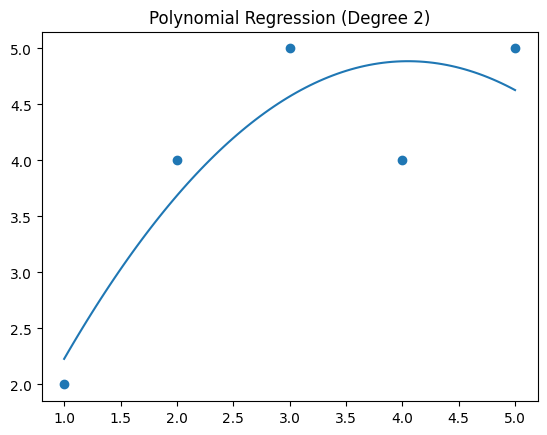

In [43]:
# sample data
x = np.array([1,2,3,4,5])
y = np.array([2,4,5,4,5])

# fit polynomial (degree 2)
coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

# plot
x_new = np.linspace(1,5,100)
plt.scatter(x, y)
plt.plot(x_new, poly(x_new))
plt.title("Polynomial Regression (Degree 2)")
plt.show()

In [ ]:
##compare linear vs polynomial regression

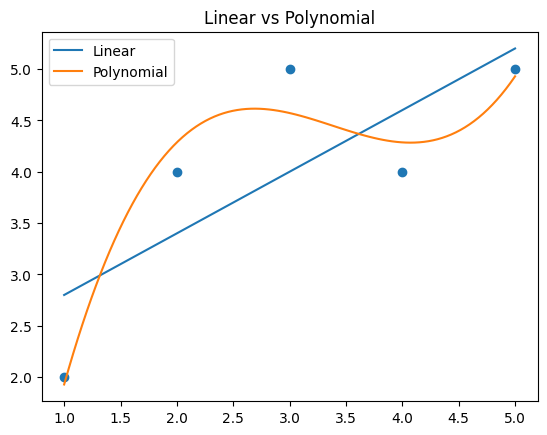

In [44]:
# linear fit
linear = np.polyfit(x, y, 1)
linear_fn = np.poly1d(linear)

# polynomial fit
poly = np.polyfit(x, y, 3)
poly_fn = np.poly1d(poly)

plt.scatter(x, y)
plt.plot(x_new, linear_fn(x_new), label="Linear")
plt.plot(x_new, poly_fn(x_new), label="Polynomial")

plt.legend()
plt.title("Linear vs Polynomial")
plt.show()

In [ ]:
prediction.ipynb

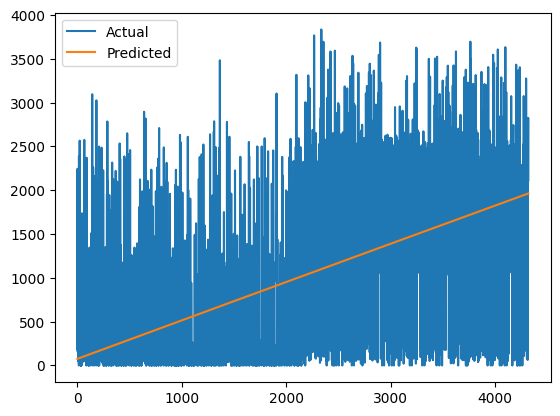

In [45]:
# Predict energy trend using polynomial
x = np.arange(len(df))
y = df['total_power']

coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

plt.plot(x, y, label="Actual")
plt.plot(x, poly(x), label="Predicted")

plt.legend()
plt.show()